In [1]:
import polars as pl

In [2]:
# Load data and examine structure
df = pl.read_parquet("../../../data/processed/df_feat_final_result_optimized.parquet")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns[:10]}...")  # Show first 10 columns

Shape: (25613290, 73)
Columns: ['ts_start', 'station_id', 'dep_last_DT', 'trip_dur_mean_last_DT', 'model_FIT_cnt', 'model_ICONIC_cnt', 'share_male', 'share_female', 'share_other', 'dep_lag_1']...


In [3]:
# Only fill nulls for columns (not weather_) that actually have nulls
null_counts = df.null_count().to_dict(as_series=False)
cols_to_fill = [col for col in df.columns if (not col.startswith('weather_')) and (null_counts[col][0] > 0)]
df = df.with_columns([pl.col(col).fill_null(0) for col in cols_to_fill])


In [4]:
df.null_count()

ts_start,station_id,dep_last_DT,trip_dur_mean_last_DT,model_FIT_cnt,model_ICONIC_cnt,share_male,share_female,share_other,dep_lag_1,dep_lag_2,dep_lag_3,dep_lag_4,dep_lag_5,dep_lag_6,arr_last_DT,arr_lag_1,arr_lag_2,arr_lag_3,arr_lag_4,arr_lag_5,arr_lag_6,y_arrivals_next_DT,y_departures_next_DT,weather_temperature_2m,weather_relative_humidity_2m,weather_dew_point_2m,weather_apparent_temperature,weather_precipitation,weather_rain,weather_weather_code,weather_pressure_msl,weather_surface_pressure,weather_cloud_cover,weather_cloud_cover_low,weather_cloud_cover_mid,weather_cloud_cover_high,weather_et0_fao_evapotranspiration,weather_vapour_pressure_deficit,weather_wind_speed_10m,weather_wind_speed_100m,weather_wind_direction_10m,weather_wind_direction_100m,weather_wind_gusts_10m,weather_soil_temperature_0_to_7cm,weather_soil_temperature_7_to_28cm,weather_soil_temperature_28_to_100cm,weather_soil_temperature_100_to_255cm,weather_soil_moisture_0_to_7cm,weather_soil_moisture_7_to_28cm,weather_soil_moisture_28_to_100cm,weather_soil_moisture_100_to_255cm,weather_sunshine_duration,weather_is_day,weather_direct_radiation,lat,lon,station_name,hour,dow,month,day,is_holiday_ar,sin_hour,cos_hour,sin_dow,cos_dow,sin_month,cos_month,is_weekend,payday_flag,vacation_season,peak_commute
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
# Probabilistic Baseline: Dual Poisson Regression -> Skellam Distribution
import numpy as np
import pandas as pd
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import skellam
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [6]:
# 1. Memory-efficient sampling BEFORE pandas conversion
print(f"Original dataset size: {df.shape[0]:,} rows")

# Sample directly from Polars (much more memory efficient)
n_sample = min(26_000_000, df.shape[0])
sample_fraction = n_sample / df.shape[0]

if sample_fraction < 1:
    # Use Polars random sampling (memory efficient)
    df_sample = df.sample(fraction=sample_fraction, seed=42)
    print(f"Sampled dataset size: {df_sample.shape[0]:,} rows ({sample_fraction*100:.1f}%)")
else:
    df_sample = df
    print(f"Sampled dataset size: {df_sample.shape[0]:,} rows ({sample_fraction*100:.1f}%)")

# Now convert only the sample to pandas
pdf = df_sample.to_pandas()
print(f"Memory usage after sampling: ~{pdf.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Clear original large dataframes
del df, df_sample

Original dataset size: 25,613,290 rows
Sampled dataset size: 25,613,290 rows (100.0%)


Memory usage after sampling: ~8840.8 MB


In [7]:
# Define targets: Δ_t = arrivals - departures 
target_A = 'y_arrivals_next_DT'
target_D = 'y_departures_next_DT'

for col in [target_A, target_D]:
    pdf[col] = pdf[col].astype(np.int64)      # o 'Int64' de pandas para nullables


pdf['delta_t'] = pdf[target_A] - pdf[target_D]

print(f"Target statistics:")
print(f"Arrivals: mean={pdf[target_A].mean():.2f}, std={pdf[target_A].std():.2f}")
print(f"Departures: mean={pdf[target_D].mean():.2f}, std={pdf[target_D].std():.2f}")
print(f"Delta: mean={pdf['delta_t'].mean():.2f}, std={pdf['delta_t'].std():.2f}")


Target statistics:
Arrivals: mean=0.41, std=0.97
Departures: mean=0.41, std=0.99
Delta: mean=0.00, std=0.97


In [8]:
print("Min and max of y_arrivals_next_DT:")
print(pdf['y_arrivals_next_DT'].min(), pdf['y_arrivals_next_DT'].max())

print("Min and max of y_departures_next_DT:")
print(pdf['y_departures_next_DT'].min(), pdf['y_departures_next_DT'].max())

print("Min and max of delta_t:")
print(pdf['delta_t'].min(), pdf['delta_t'].max())



Min and max of y_arrivals_next_DT:
0 31
Min and max of y_departures_next_DT:
0 31
Min and max of delta_t:
-26 21


In [9]:
# 2. Minimal feature set (available at prediction time)
feature_cols = [
 'dep_last_DT', # "station_id",   # removed for generalization
 'trip_dur_mean_last_DT',
 'dep_lag_1',
 'dep_lag_2',
 'dep_lag_3',
 'dep_lag_4',
 'dep_lag_5',
 'dep_lag_6',
 'arr_last_DT',
 'arr_lag_1',
 'arr_lag_2',
 'arr_lag_3',
 'arr_lag_4',
 'arr_lag_5',
 'arr_lag_6',
 'weather_temperature_2m',
 'weather_relative_humidity_2m',
 'weather_apparent_temperature',
 'weather_precipitation',
 'weather_wind_speed_10m',
 'weather_sunshine_duration',
 'weather_is_day',
 'lat',
 'lon',
 #'station_name',
 #'hour',
 #'dow',
 #'month',
 #'day',
 'is_holiday_ar',
 'sin_hour',
 'cos_hour',
 'sin_dow',
 'cos_dow',
 'sin_month',
 'cos_month',
 'is_weekend',
 'payday_flag',
 'vacation_season',
 'peak_commute']

print(f"Selected {len(feature_cols)} features")


Selected 35 features


In [11]:
# Geographic Clustering with GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import seaborn as sns

# 1. Extract unique stations with coordinates
print("Extracting unique stations...")
unique_stations = pdf[['station_id', 'lat', 'lon']].drop_duplicates('station_id')
print(f"Found {len(unique_stations)} unique stations")

# 2. Prepare coordinates for clustering
coords = unique_stations[['lat', 'lon']].values
print(f"Coordinate range: lat=[{coords[:, 0].min():.4f}, {coords[:, 0].max():.4f}], lon=[{coords[:, 1].min():.4f}, {coords[:, 1].max():.4f}]")

# Scale coordinates for GMM
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)


Extracting unique stations...
Found 398 unique stations
Coordinate range: lat=[-34.6878, -34.5367], lon=[-58.5271, -58.3555]


In [12]:
# 3. Find optimal number of clusters using silhouette score
cluster_range = range(41, 100)  # Test 2 to 14 clusters
silhouette_scores = []
models = {}

print("Testing different numbers of clusters...")
for n_clusters in cluster_range:
    # Fit GMM
    gmm = GaussianMixture(n_components=n_clusters, random_state=42, n_init=5)
    cluster_labels = gmm.fit_predict(coords_scaled)
    
    # Calculate silhouette score
    sil_score = silhouette_score(coords_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    models[n_clusters] = gmm
    
    print(f"n_clusters={n_clusters:2d}: silhouette_score={sil_score:.4f}")

# Find optimal number of clusters
optimal_n_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_n_clusters}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

# Get the optimal model and final cluster assignments
best_gmm = models[optimal_n_clusters]
final_clusters = best_gmm.predict(coords_scaled)
unique_stations['cluster'] = final_clusters


Testing different numbers of clusters...
n_clusters=41: silhouette_score=0.1951
n_clusters=42: silhouette_score=0.1983
n_clusters=43: silhouette_score=0.2002
n_clusters=44: silhouette_score=0.1721
n_clusters=45: silhouette_score=0.2098
n_clusters=46: silhouette_score=0.1848
n_clusters=47: silhouette_score=0.1865
n_clusters=48: silhouette_score=0.2075
n_clusters=49: silhouette_score=0.1918
n_clusters=50: silhouette_score=0.1781
n_clusters=51: silhouette_score=0.1823
n_clusters=52: silhouette_score=0.1637
n_clusters=53: silhouette_score=0.2056
n_clusters=54: silhouette_score=0.1684
n_clusters=55: silhouette_score=0.1568
n_clusters=56: silhouette_score=0.1807
n_clusters=57: silhouette_score=0.1926
n_clusters=58: silhouette_score=0.1872
n_clusters=59: silhouette_score=0.1980
n_clusters=60: silhouette_score=0.1694
n_clusters=61: silhouette_score=0.1521
n_clusters=62: silhouette_score=0.1626
n_clusters=63: silhouette_score=0.1569
n_clusters=64: silhouette_score=0.2257
n_clusters=65: silhouet

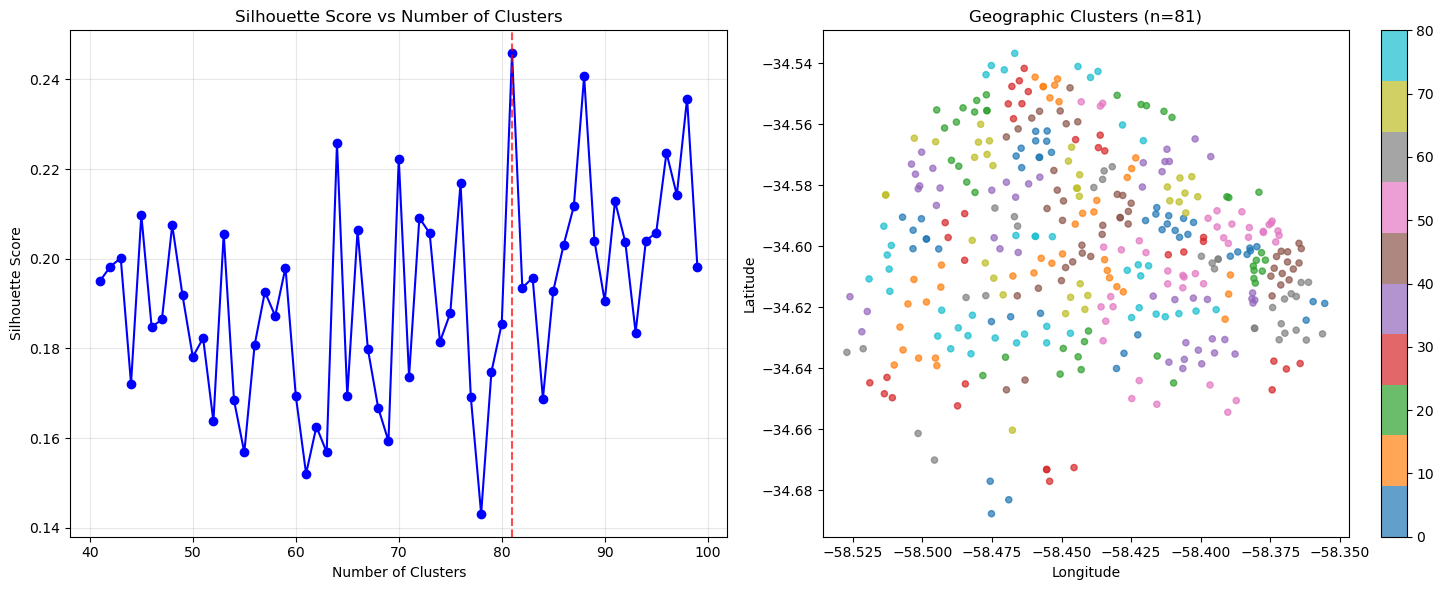


Cluster distribution:
Cluster 0: 7 stations (1.8%)
Cluster 1: 11 stations (2.8%)
Cluster 2: 3 stations (0.8%)
Cluster 3: 10 stations (2.5%)
Cluster 4: 3 stations (0.8%)
Cluster 5: 3 stations (0.8%)
Cluster 6: 6 stations (1.5%)
Cluster 7: 3 stations (0.8%)
Cluster 8: 3 stations (0.8%)
Cluster 9: 5 stations (1.3%)
Cluster 10: 5 stations (1.3%)
Cluster 11: 7 stations (1.8%)
Cluster 12: 3 stations (0.8%)
Cluster 13: 4 stations (1.0%)
Cluster 14: 6 stations (1.5%)
Cluster 15: 5 stations (1.3%)
Cluster 16: 2 stations (0.5%)
Cluster 17: 3 stations (0.8%)
Cluster 18: 9 stations (2.3%)
Cluster 19: 8 stations (2.0%)
Cluster 20: 4 stations (1.0%)
Cluster 21: 6 stations (1.5%)
Cluster 22: 5 stations (1.3%)
Cluster 23: 2 stations (0.5%)
Cluster 24: 4 stations (1.0%)
Cluster 25: 4 stations (1.0%)
Cluster 26: 4 stations (1.0%)
Cluster 27: 4 stations (1.0%)
Cluster 28: 4 stations (1.0%)
Cluster 29: 7 stations (1.8%)
Cluster 30: 4 stations (1.0%)
Cluster 31: 2 stations (0.5%)
Cluster 32: 5 stations (1

In [13]:
# 4. Visualize clustering results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot silhouette scores
ax1.plot(cluster_range, silhouette_scores, 'bo-')
ax1.axvline(x=optimal_n_clusters, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs Number of Clusters')
ax1.grid(True, alpha=0.3)

# Plot geographic clusters
scatter = ax2.scatter(unique_stations['lon'], unique_stations['lat'], 
                     c=unique_stations['cluster'], cmap='tab10', s=20, alpha=0.7)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title(f'Geographic Clusters (n={optimal_n_clusters})')
plt.colorbar(scatter, ax=ax2)

plt.tight_layout()
plt.show()

# Print cluster statistics
print(f"\nCluster distribution:")
cluster_counts = unique_stations['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} stations ({count/len(unique_stations)*100:.1f}%)")


In [16]:
# 5. Add cluster labels to the main dataset
print("Adding cluster labels to the main dataset...")

# Compute demand lags: dem_lag_i = arr_lag_i - dep_lag_i
demand_lag_cols = []
for i in range(1, 7):  # lags 1-6
    dem_lag_col = f'dem_lag_{i}'
    arr_lag_col = f'arr_lag_{i}'
    dep_lag_col = f'dep_lag_{i}'
    
    if arr_lag_col in pdf.columns and dep_lag_col in pdf.columns:
        pdf[dem_lag_col] = pdf[arr_lag_col] - pdf[dep_lag_col]
        demand_lag_cols.append(dem_lag_col)
        feature_cols.append(dem_lag_col)

# Compute demand target: target = y_arr - y_dep
pdf['y_demand_next_DT'] = pdf[target_A] - pdf[target_D]

import gc
gc.collect()

# Merge cluster assignments back to the main dataset
pdf_clustered = pdf.merge(unique_stations[['station_id', 'cluster']], on='station_id', how='left')

# Verify the merge
print(f"Original dataset shape: {pdf.shape}")
print(f"Clustered dataset shape: {pdf_clustered.shape}")
print(f"Samples with cluster labels: {pdf_clustered['cluster'].notna().sum()}/{len(pdf_clustered)}")

# Check cluster distribution in the full dataset
cluster_dist = pdf_clustered['cluster'].value_counts().sort_index()
print(f"\nCluster distribution in full dataset:")
for cluster_id, count in cluster_dist.items():
    print(f"Cluster {cluster_id}: {count:,} samples ({count/len(pdf_clustered)*100:.1f}%)")


Adding cluster labels to the main dataset...
Original dataset shape: (25613290, 81)
Clustered dataset shape: (25613290, 82)
Samples with cluster labels: 25613290/25613290

Cluster distribution in full dataset:
Cluster 0: 450,485 samples (1.8%)
Cluster 1: 707,905 samples (2.8%)
Cluster 2: 193,065 samples (0.8%)
Cluster 3: 643,550 samples (2.5%)
Cluster 4: 193,065 samples (0.8%)
Cluster 5: 193,065 samples (0.8%)
Cluster 6: 386,130 samples (1.5%)
Cluster 7: 193,065 samples (0.8%)
Cluster 8: 193,065 samples (0.8%)
Cluster 9: 321,775 samples (1.3%)
Cluster 10: 321,775 samples (1.3%)
Cluster 11: 450,485 samples (1.8%)
Cluster 12: 193,065 samples (0.8%)
Cluster 13: 257,420 samples (1.0%)
Cluster 14: 386,130 samples (1.5%)
Cluster 15: 321,775 samples (1.3%)
Cluster 16: 128,710 samples (0.5%)
Cluster 17: 193,065 samples (0.8%)
Cluster 18: 579,195 samples (2.3%)
Cluster 19: 514,840 samples (2.0%)
Cluster 20: 257,420 samples (1.0%)
Cluster 21: 386,130 samples (1.5%)
Cluster 22: 321,775 samples (1

In [17]:
# 6. Save the clustered dataset using chunked writing
import os
import gc
from pathlib import Path
import polars as pl

def write_parquet_streaming(
    df: pl.DataFrame,
    path: str | Path,
    *,
    compression: str = "snappy",
    row_group_size: int = 10_000,
) -> None:
    """
    Persist a large Polars DataFrame to Parquet using the built-in streaming engine.

    Parameters
    ----------
    df : pl.DataFrame
        DataFrame to write.
    path : str | pathlib.Path
        Destination file path.
    compression : {'snappy', 'zstd', 'gzip', 'lz4', 'uncompressed'}, default 'snappy'
        Parquet compression codec.
    row_group_size : int, default 10_000
        Row-group size (balance between seek-time and file size).

    Notes
    -----
    * The function relies on Polars' streaming sink, which writes the data
      incrementally without reading it back or mmap-locking the file.
    * Works best with Polars ≥ 1.0, but the `engine="streaming"` flag is added
      explicitly for clarity.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    # Lazy frame → streaming sink
    (
        df.lazy()
          .sink_parquet(
              path.as_posix(),
              compression=compression,
              row_group_size=row_group_size,
              engine="streaming",          # explicit; Polars picks streaming automatically on large frames
          )
    )

    print(f"✅ Saved {df.height:,} rows to {path.resolve()}")


# Create output directory if it doesn't exist
output_dir = "../../../data/processed/"
os.makedirs(output_dir, exist_ok=True)

# Convert back to Polars for efficient chunked saving
print("Converting to Polars for chunked saving...")
df_clustered_pl = pl.from_pandas(pdf_clustered)

# Save as parquet using chunked writing
output_file = os.path.join(output_dir, "df_feat_final_clustered.parquet")
print(f"Saving clustered dataset to: {output_file}")
write_parquet_streaming(df_clustered_pl, output_file, row_group_size=100000)
print(f"File size: ~{os.path.getsize(output_file) / 1e6:.1f} MB")

# Clear memory
del df_clustered_pl
gc.collect()

# Also save the station-cluster mapping for future use
mapping_file = os.path.join(output_dir, "station_cluster_mapping.csv")
unique_stations.to_csv(mapping_file, index=False)
print(f"Saved station-cluster mapping to: {mapping_file}")

# Save clustering model for future predictions
import joblib
model_file = os.path.join(output_dir, "geographic_clustering_model.pkl")
joblib.dump({
    'gmm_model': best_gmm,
    'scaler': scaler_geo,
    'n_clusters': optimal_n_clusters,
    'silhouette_score': max(silhouette_scores)
}, model_file)
print(f"Saved clustering model to: {model_file}")


Converting to Polars for chunked saving...
Saving clustered dataset to: ../../../data/processed/df_feat_final_clustered.parquet
✅ Saved 25,613,290 rows to C:\Users\xxx\Documents\GitHub\EcoBici-AI\data\processed\df_feat_final_clustered.parquet
File size: ~1477.5 MB
Saved station-cluster mapping to: ../../../data/processed/station_cluster_mapping.csv
Saved clustering model to: ../../../data/processed/geographic_clustering_model.pkl
